# Wheat Leaf Disease Detection & Treatment Recommendation System

A deep-learning image classifier combined with a rule-based recommendation module for wheat leaf diseases.

**Diseases covered:** Yellow Rust (YR), Brown Rust (BR), and Healthy leaves.

This notebook implements the full pipeline described in `doc.md`:

| Step | Description |
|------|-------------|
| 1 | Data acquisition & 70:30 train/validation split |
| 2 | Image preprocessing (256×256 RGB) |
| 3 | Custom CNN architecture (6 conv + 6 max-pool + dense + softmax) |
| 4 | Model training (Adam, batch size 32, 50 epochs) |
| 5 | Rule-based recommendation module (regex + REST API) |
| 6 | Web application integration |
| 7 | Privacy & security configuration (non-persistent processing) |

> **Dataset:** A publicly available Kaggle wheat-leaf dataset (~3,679 images). See Step 1 for how to obtain and arrange it.

## Setup: Install & Import Dependencies

Run this once. On Google Colab most of these are pre-installed; uncomment the `pip install` line if anything is missing.

In [1]:
# !pip install tensorflow numpy matplotlib scikit-learn pillow flask flask-cors

import os
import json
import re
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Global Configuration

Central place for all hyperparameters so they match the paper's specification.

In [ ]:
# ---- Image / data settings ----
IMG_SIZE     = (256, 256)      # Step 2: standardize to 256 x 256
IMG_CHANNELS = 3               # RGB
INPUT_SHAPE  = IMG_SIZE + (IMG_CHANNELS,)

# ---- Class labels ----
# Canonical labels used by the model, reports, the recommendation DB and app.py.
CLASS_NAMES = ['Brown_Rust', 'Healthy', 'Yellow_Rust']
NUM_CLASSES = len(CLASS_NAMES)

# ---- Training settings (Step 4) ----
BATCH_SIZE    = 32      # batch size 32   (paper)
EPOCHS        = 50      # 50 epochs       (paper)
LEARNING_RATE = 1e-4    # paper does not state a learning rate

# ---------------------------------------------------------------------------
# REPLICATION CONTROLS
#
# STRICT_PAPER_MODE = True  -> run exactly the paper's protocol:
#     * all 50 epochs, no EarlyStopping (paper says "epochs = 50", full stop)
#     * no data augmentation      (paper never mentions it)
#     * no dropout                (not in the paper's architecture)
#     * no ReduceLROnPlateau      (not in the paper)
#   The headline metric is then the FINAL-EPOCH model, which is what "trained
#   for 50 epochs" actually produces.
#
# STRICT_PAPER_MODE = False -> the improved setup (augmentation + dropout +
#   EarlyStopping on val_accuracy). Better generalization, but a deviation you
#   must disclose if you claim replication.
#
# Run it BOTH ways and report both numbers -- that is the honest write-up.
# ---------------------------------------------------------------------------
STRICT_PAPER_MODE = True

USE_AUGMENTATION = not STRICT_PAPER_MODE
DROPOUT_RATE     = 0.0 if STRICT_PAPER_MODE else 0.5

# ---- Split (Step 1) ----
# The Kaggle dataset ships pre-split 80:20 (2942 train / 737 val), but the paper
# specifies 70:30. RESPLIT_70_30 pools all 3679 images and re-splits them to match.
RESPLIT_70_30 = True
TRAIN_SPLIT   = 0.70
VAL_SPLIT     = 0.30
RESPLIT_ROOT  = ('/kaggle/working/data_70_30' if os.path.isdir('/kaggle/working')
                 else 'data_70_30')

# ---- Paths ----
# The paper's dataset (kaggle.com/datasets/sinadunk23/behzad-safari-jalal, 3679 images)
# ships pre-split on disk as data/train/<class>/*.jpg and data/val/<class>/*.jpg.
# Step 1 re-splits it once to 70:30 and repoints TRAIN_DIR / VAL_DIR at the result,
# so no cell ever needs ImageDataGenerator(validation_split=...).
import glob

DATA_ROOT_OVERRIDE = '/kaggle/input/behzad-safari-jalal/data'

def _resolve_class_dirs(split_dir):
    """Map canonical CLASS_NAMES -> real on-disk folder names, case-insensitively.
    The dataset ships 'Brown_rust'/'Healthy'/'Yellow_rust'; this tolerates other
    casings so a re-upload with different capitalization still works."""
    if not os.path.isdir(split_dir):
        return None
    on_disk = {d.lower(): d for d in os.listdir(split_dir)
               if os.path.isdir(os.path.join(split_dir, d))}
    resolved = []
    for c in CLASS_NAMES:
        hit = on_disk.get(c.lower())
        if hit is None:
            return None
        resolved.append(hit)
    return resolved

def _is_valid_root(root):
    return (_resolve_class_dirs(os.path.join(root, 'train')) is not None
            and _resolve_class_dirs(os.path.join(root, 'val')) is not None)

def _find_data_root():
    if DATA_ROOT_OVERRIDE and _is_valid_root(DATA_ROOT_OVERRIDE):
        return DATA_ROOT_OVERRIDE
    # Auto-detect: any directory holding train/ and val/ with the 3 class folders.
    for base in ('/kaggle/input', 'archive', '.'):
        if not os.path.isdir(base):
            continue
        for cand in sorted(glob.glob(os.path.join(base, '**', 'train'), recursive=True)):
            root = os.path.dirname(cand)
            if _is_valid_root(root):
                return root
    return 'wheat_leaf_dataset'     # synthetic fallback, built in Step 1

DATA_ROOT  = _find_data_root()
TRAIN_DIR  = os.path.join(DATA_ROOT, 'train')
VAL_DIR    = os.path.join(DATA_ROOT, 'val')
MODEL_PATH = 'wheat_disease_cnn.keras'

print("Classes   :", CLASS_NAMES)
print("Data root :", DATA_ROOT)
if _is_valid_root(DATA_ROOT):
    print("Train dir :", TRAIN_DIR, "->", _resolve_class_dirs(TRAIN_DIR))
    print("Val dir   :", VAL_DIR, "->", _resolve_class_dirs(VAL_DIR))
else:
    print("WARNING: real dataset not found -> Step 1 will build synthetic demo data.")
    print("         Check that the 'Wheat Disease Detection' dataset is attached.")


## Step 1 - Data Acquisition and Splitting

This notebook uses the **exact dataset cited in the paper**:
[`sinadunk23/behzad-safari-jalal`](https://www.kaggle.com/datasets/sinadunk23/behzad-safari-jalal)
- **3,679 images** across Yellow Rust, Brown Rust and Healthy.

### Folder layout as shipped

```
data/
|-- train/
|   |-- Brown_rust/    *.jpg
|   |-- Healthy/       *.jpg
|   `-- Yellow_rust/   *.jpg
`-- val/
    |-- Brown_rust/    *.jpg
    |-- Healthy/       *.jpg
    `-- Yellow_rust/   *.jpg
```

The dataset ships **pre-split 80:20** (2942 train / 737 val) but the paper specifies
**70:30**, so the next two cells do this:

1. **Find or build the dataset**, then report the counts it shipped with.
2. **Split it 70:30 once**, pooling all 3,679 images and writing a new `train/` and
   `val/` pair. Files are grouped by md5 **before** splitting, so byte-identical
   duplicates always land on the same side - a naive random split would scatter
   copies of one photograph across both sides and manufacture leakage the original
   split never had.

After that the split is fixed: `TRAIN_DIR` and `VAL_DIR` point at the 70:30 folders
and every later cell just reads them. Set `RESPLIT_70_30 = False` in the config cell
to keep the dataset's own 80:20 split instead.

If the dataset is not attached, a small **synthetic** stand-in is built so the rest
of the notebook still runs.


In [ ]:
import hashlib
from PIL import Image

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')


# ---- small helpers, defined once and reused by every cell below ----
def list_images(directory):
    """Full paths of the image files directly inside `directory`."""
    if not os.path.isdir(directory):
        return []
    return [os.path.join(directory, f) for f in sorted(os.listdir(directory))
            if f.lower().endswith(IMG_EXTS)]


def file_md5(path):
    """Hash of the raw file bytes, used to spot byte-identical duplicates."""
    with open(path, 'rb') as fh:
        return hashlib.md5(fh.read()).hexdigest()


def print_split_table(rows):
    """rows = [(class name, n_train, n_val), ...]. Returns the total image count."""
    print(f"{'Class':14s}{'train':>8s}{'val':>8s}{'total':>8s}{'val %':>8s}")
    print('-' * 46)
    tr_tot = va_tot = 0
    for name, tr, va in rows:
        tr_tot += tr
        va_tot += va
        print(f"{name:14s}{tr:8d}{va:8d}{tr + va:8d}{100 * va / max(1, tr + va):7.1f}%")
    print('-' * 46)
    total = tr_tot + va_tot
    print(f"{'TOTAL':14s}{tr_tot:8d}{va_tot:8d}{total:8d}"
          f"{100 * va_tot / max(1, total):7.1f}%")
    return total


def count_rows(train_dir, val_dir, train_folders, val_folders):
    """Per-class (name, n_train, n_val) for one train/val pair of directories."""
    return [(name,
             len(list_images(os.path.join(train_dir, trd))),
             len(list_images(os.path.join(val_dir, vad))))
            for name, trd, vad in zip(CLASS_NAMES, train_folders, val_folders)]


def build_synthetic_dataset(root, per_class_train=42, per_class_val=18):
    """Colored-noise placeholders so the notebook runs end-to-end without the real
    dataset. Mirrors the real layout: <root>/train/<class> and <root>/val/<class>."""
    tints = {'Brown_rust': (139, 69, 19), 'Healthy': (34, 139, 34), 'Yellow_rust': (218, 165, 32)}
    for split, n in (('train', per_class_train), ('val', per_class_val)):
        for cls, tint in tints.items():
            d = os.path.join(root, split, cls)
            os.makedirs(d, exist_ok=True)
            for i in range(n):
                noise = np.random.randint(0, 60, IMG_SIZE + (3,), dtype=np.uint8)
                arr = np.clip(noise + np.array(tint, dtype=np.int16), 0, 255).astype(np.uint8)
                Image.fromarray(arr).save(os.path.join(d, f'{cls}_{split}_{i:03d}.png'))
    print(f"Synthetic dataset created at '{root}' "
          f"(train {per_class_train}/class, val {per_class_val}/class).")


if not _is_valid_root(DATA_ROOT):
    print(f"'{DATA_ROOT}' is not a valid train/val root -> generating synthetic demo data.")
    print("Attach the real Kaggle dataset for actual training.\n")
    build_synthetic_dataset(DATA_ROOT)

# Resolve real on-disk folder names now that the data definitely exists.
TRAIN_CLASS_DIRS = _resolve_class_dirs(TRAIN_DIR)
VAL_CLASS_DIRS   = _resolve_class_dirs(VAL_DIR)
assert TRAIN_CLASS_DIRS and VAL_CLASS_DIRS, f"Class folders not found under {DATA_ROOT}"

print("\nSplit as shipped by the dataset:\n")
found = print_split_table(count_rows(TRAIN_DIR, VAL_DIR, TRAIN_CLASS_DIRS, VAL_CLASS_DIRS))

print("\nPaper (Table 2): Yellow_Rust 1156 | Brown_Rust 1128 | Healthy 1395 | total 3679")
if found != 3679:
    print(f"!! NOTE: found {found} images, the paper reports 3679 -- counts differ.")


In [ ]:
# ============================================================================
# THE 70:30 SPLIT (paper Section 3.1) - performed here, once.
# ----------------------------------------------------------------------------
# Everything downstream reads TRAIN_DIR / VAL_DIR, which this cell repoints at the
# new split. Duplicate images are grouped by md5 first so copies of one photograph
# cannot end up on both sides.
# ============================================================================
if RESPLIT_70_30:
    import shutil
    from collections import defaultdict

    rng = np.random.RandomState(SEED)
    rows = []
    print(f"Splitting {TRAIN_SPLIT:.0%}:{VAL_SPLIT:.0%} -> {RESPLIT_ROOT}\n")

    for name, trd, vad in zip(CLASS_NAMES, TRAIN_CLASS_DIRS, VAL_CLASS_DIRS):
        # 1. pool every image of this class from both shipped splits
        pool = (list_images(os.path.join(TRAIN_DIR, trd))
                + list_images(os.path.join(VAL_DIR, vad)))

        # 2. group byte-identical files so duplicates cannot straddle the split
        groups = defaultdict(list)
        for path in pool:
            groups[file_md5(path)].append(path)
        keys = sorted(groups)
        rng.shuffle(keys)

        # 3. give whole duplicate-groups to train until the 70% quota is met
        quota = int(round(TRAIN_SPLIT * len(pool)))
        assigned, side = 0, {}
        for key in keys:
            side[key] = 'train' if assigned < quota else 'val'
            assigned += len(groups[key])

        # 4. write the new split (symlink where the filesystem allows it, else copy)
        counts = {'train': 0, 'val': 0}
        for key in keys:
            target_dir = os.path.join(RESPLIT_ROOT, side[key], name)
            os.makedirs(target_dir, exist_ok=True)
            for path in groups[key]:
                dst = os.path.join(target_dir, os.path.basename(path))
                if not os.path.exists(dst):
                    try:
                        os.symlink(os.path.abspath(path), dst)
                    except OSError:
                        shutil.copy2(path, dst)
                counts[side[key]] += 1
        rows.append((name, counts['train'], counts['val']))

    print_split_table(rows)

    # 5. repoint every downstream path at the new split
    DATA_ROOT = RESPLIT_ROOT
    TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
    VAL_DIR   = os.path.join(DATA_ROOT, 'val')
    TRAIN_CLASS_DIRS = _resolve_class_dirs(TRAIN_DIR)
    VAL_CLASS_DIRS   = _resolve_class_dirs(VAL_DIR)
    assert TRAIN_CLASS_DIRS and VAL_CLASS_DIRS, 'class folders missing after the split'
    print(f"\nActive data root: {DATA_ROOT}  (paper-aligned 70:30)")
else:
    print("RESPLIT_70_30 = False -> keeping the dataset's own 80:20 split.")
    print("NOTE: this deviates from the paper's stated 70:30 -- disclose it.")


## Step 2 - Image Preprocessing

Standardize every image to **256x256 RGB** and rescale pixel values to `[0, 1]`.

The 70:30 split already exists on disk from Step 1, so each generator simply reads
its own directory - neither one uses `validation_split`. Light augmentation is added
to the training stream only, and only when `STRICT_PAPER_MODE = False`.


In [5]:
# The dataset is ALREADY split on disk, so each generator reads its own directory
# and neither one uses validation_split.
aug_kwargs = dict(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
) if USE_AUGMENTATION else {}

train_datagen = ImageDataGenerator(rescale=1.0 / 255, **aug_kwargs)
val_datagen   = ImageDataGenerator(rescale=1.0 / 255)   # val: rescale only, never augmented

# classes=<on-disk folder names>, given in the SAME order as CLASS_NAMES, so class
# index i always maps to CLASS_NAMES[i] everywhere downstream.
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TRAIN_CLASS_DIRS,
    shuffle=True,
    seed=SEED,
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=VAL_CLASS_DIRS,
    shuffle=False,   # MUST stay False so val_gen.classes aligns with predict() output
)

# Guard: both generators must agree on which folder is which index.
_tr = [k.lower() for k in train_gen.class_indices]
_va = [k.lower() for k in val_gen.class_indices]
assert _tr == _va, f"train/val class order differs: {_tr} vs {_va}"

print("\nTrain class_indices:", train_gen.class_indices)
print("Val   class_indices:", val_gen.class_indices)
print("Index -> label     :", dict(enumerate(CLASS_NAMES)))
print(f"\ntrain: {train_gen.samples} images  |  val: {val_gen.samples} images  "
      f"({100 * val_gen.samples / (train_gen.samples + val_gen.samples):.1f}% val)")


Found 2575 images belonging to 3 classes.
Found 1104 images belonging to 3 classes.

Train class_indices: {'Brown_Rust': 0, 'Healthy': 1, 'Yellow_Rust': 2}
Val   class_indices: {'Brown_Rust': 0, 'Healthy': 1, 'Yellow_Rust': 2}
Index -> label     : {0: 'Brown_Rust', 1: 'Healthy', 2: 'Yellow_Rust'}

train: 2575 images  |  val: 1104 images  (30.0% val)


### Data integrity check — train/val leakage

The single most important check for reproducing the paper's **96%**. If the same
photograph appears in both `train/` and `val/`, the model can memorize it and the
validation score drifts toward the *training* score — which is exactly the failure
mode that produces a suspiciously high headline number with a small from-scratch CNN.

This cell hashes every file's raw bytes and reports exact duplicates within and
across the two splits.


In [ ]:
# ============================================================================
# LEAKAGE AUDIT - is any val image byte-identical to a train image?
# ----------------------------------------------------------------------------
# If the same photograph sits on both sides, validation accuracy drifts toward
# training accuracy and stops being a generalization estimate. The split in Step 1
# keeps duplicate groups together, so this should report zero overlap - this cell
# is the proof, and it also covers the RESPLIT_70_30 = False case.
# ============================================================================
from collections import defaultdict


def hash_split(split_dir, class_dirs):
    """md5(file bytes) -> ['<class folder>/<file name>', ...]."""
    hashes = defaultdict(list)
    for folder in class_dirs:
        for path in list_images(os.path.join(split_dir, folder)):
            hashes[file_md5(path)].append(f'{folder}/{os.path.basename(path)}')
    return hashes


train_h = hash_split(TRAIN_DIR, TRAIN_CLASS_DIRS)
val_h   = hash_split(VAL_DIR,   VAL_CLASS_DIRS)

n_train = sum(len(v) for v in train_h.values())
n_val   = sum(len(v) for v in val_h.values())
dup_train = sum(len(v) - 1 for v in train_h.values() if len(v) > 1)
dup_val   = sum(len(v) - 1 for v in val_h.values()   if len(v) > 1)

overlap  = set(train_h) & set(val_h)
n_leaked = sum(len(val_h[k]) for k in overlap)

print(f"train images            : {n_train} ({len(train_h)} unique)")
print(f"val   images            : {n_val} ({len(val_h)} unique)")
print(f"duplicates within train : {dup_train}")
print(f"duplicates within val   : {dup_val}")
print(f"\nEXACT train/val overlap : {len(overlap)} distinct images "
      f"-> {n_leaked} val images ({100 * n_leaked / max(1, n_val):.2f}% of val)")

if overlap:
    print("\n!! LEAKAGE DETECTED - validation accuracy will be inflated.")
    print("   Examples (same bytes on both sides):")
    for k in list(overlap)[:10]:
        print(f"     train:{train_h[k][0]}   ==   val:{val_h[k][0]}")
    print("\n   -> Treat the headline accuracy as optimistic, and/or de-duplicate")
    print("      before reporting. LEAKED_VAL_FILES below lists every affected file.")
    LEAKED_VAL_FILES = sorted(f for k in overlap for f in val_h[k])
else:
    LEAKED_VAL_FILES = []
    print("\nNo byte-identical images shared between train and val.")
    print("Split is clean at the exact-duplicate level.")
    print("(Caveat: this does not catch re-encoded, resized or crop-shifted near-duplicates.)")


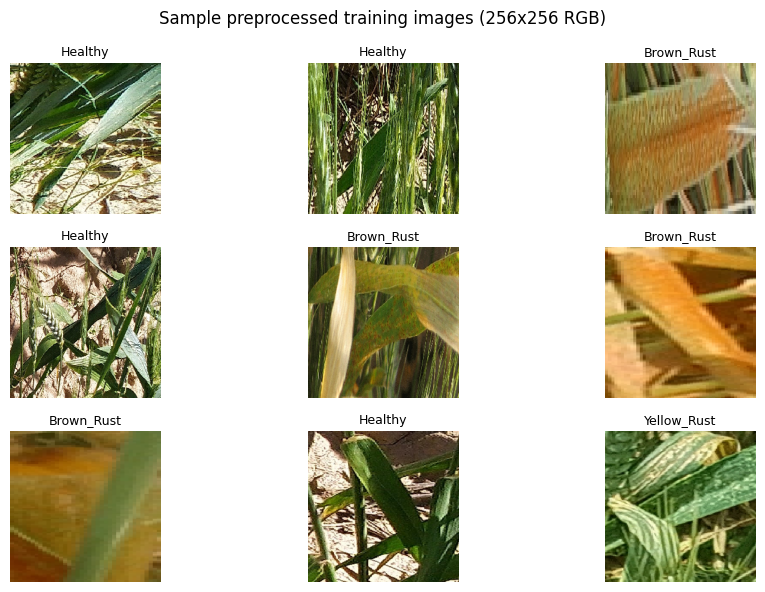

In [7]:
# Visualize a batch to confirm preprocessing looks right
images, labels = next(train_gen)
plt.figure(figsize=(10, 6))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[np.argmax(labels[i])], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample preprocessed training images (256x256 RGB)')
plt.tight_layout()
plt.show()

# Reset generator after peeking so training starts from a clean state
train_gen.reset()

## Step 3 — CNN Architecture Design

A custom CNN as specified:

- **6 convolutional layers** — 3×3 kernels, ReLU activation, for feature extraction
- **6 max-pooling layers** — one after each conv layer, to shrink the feature maps and reduce the training vector space
- **Dense (fully connected) layer** — after the final pooling stage, for learning/prediction
- **Output layer** — SoftMax classifier over the 3 classes

Starting from 256×256 and halving six times (256→128→64→32→16→8→4) leaves a 4×4 spatial map before flattening — a clean fit for six pooling stages.

In [8]:
def build_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
              dropout_rate=DROPOUT_RATE):
    """Custom CNN: 6 x (Conv3x3 + ReLU + MaxPool) -> Dense -> SoftMax.

    Matches the paper's Section 3.2 architecture exactly. Dropout is NOT part of
    that spec, so dropout_rate=0.0 (STRICT_PAPER_MODE) omits the layer entirely.
    """
    model = models.Sequential(name='WheatLeafCNN')
    model.add(layers.Input(shape=input_shape))

    filters = [32, 64, 128, 128, 256, 256]  # 6 conv layers
    for i, f in enumerate(filters, start=1):
        # strides=(1,1) is the paper's "one-pixel convolution cadence"
        model.add(layers.Conv2D(f, (3, 3), strides=(1, 1), activation='relu',
                                padding='same', name=f'conv{i}'))
        model.add(layers.MaxPooling2D((2, 2), name=f'pool{i}'))  # 6 max-pool layers

    # Fully connected head: one FC layer, then the SoftMax classifier
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='dense'))
    if dropout_rate and dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate, name='dropout'))   # off in strict mode
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    return model

model = build_cnn()
model.summary()
print(f"\nSTRICT_PAPER_MODE = {STRICT_PAPER_MODE} | dropout_rate = {DROPOUT_RATE} "
      f"| augmentation = {USE_AUGMENTATION}")


I0000 00:00:1784472816.769999      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "WheatLeafCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool6 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,175,683 (8.30 MB)

 Trainable params: 2,175,683 (8.30 MB)

 Non-trainable params: 0 (0.00 B)


STRICT_PAPER_MODE = True | dropout_rate = 0.0 | augmentation = False


### Step 3 validation — confirm the architecture is identical to the spec

The cell below programmatically checks the built model against `doc.md` Step 3 and **raises an `AssertionError` if anything deviates**. It verifies: exactly 6 Conv2D layers (all 3×3 + ReLU), exactly 6 MaxPooling2D layers, strict Conv→Pool alternation, a hidden Dense layer, and a SoftMax output over the class count.

In [9]:
# ============================================================================
# ARCHITECTURE VALIDATION - assert the CNN is IDENTICAL to the doc.md spec
# ----------------------------------------------------------------------------
# doc.md Step 3 requires EXACTLY:
#   * 6 Convolutional layers  -> 3x3 kernels, ReLU activation
#   * 6 Max-Pooling layers    -> one between/after each conv layer
#   * 1 Dense (fully connected) layer after the final pooling stage
#   * 1 Output layer          -> SoftMax classifier
# This cell fails loudly if any requirement is not met.
# ============================================================================

conv_layers  = [l for l in model.layers if isinstance(l, layers.Conv2D)]
pool_layers  = [l for l in model.layers if isinstance(l, layers.MaxPooling2D)]
dense_layers = [l for l in model.layers if isinstance(l, layers.Dense)]

# 1) Exactly six convolutional layers
assert len(conv_layers) == 6, f'Expected 6 Conv2D layers, found {len(conv_layers)}'

# 2) Every conv layer uses a 3x3 kernel and ReLU activation
for l in conv_layers:
    assert tuple(l.kernel_size) == (3, 3), f'{l.name}: kernel {l.kernel_size} != (3, 3)'
    assert l.activation.__name__ == 'relu', f'{l.name}: activation {l.activation.__name__} != relu'

# 3) Exactly six max-pooling layers
assert len(pool_layers) == 6, f'Expected 6 MaxPooling2D layers, found {len(pool_layers)}'

# 4) Conv and pool strictly alternate (a pool immediately follows each conv)
feature_extractor = [l for l in model.layers if isinstance(l, (layers.Conv2D, layers.MaxPooling2D))]
expected_pattern = ['Conv2D', 'MaxPooling2D'] * 6
actual_pattern = [type(l).__name__ for l in feature_extractor]
assert actual_pattern == expected_pattern, 'Conv/Pool layers do not alternate as Conv->Pool x6'

# 5) A dense hidden layer exists after flattening (the learning/prediction layer)
assert len(dense_layers) >= 2, 'Expected a hidden Dense layer plus the output Dense layer'
hidden_dense = dense_layers[-2]
assert hidden_dense.activation.__name__ == 'relu', 'Hidden Dense layer should use ReLU'

# 6) Output layer is Dense with SoftMax over NUM_CLASSES units
output_layer = dense_layers[-1]
assert output_layer.units == NUM_CLASSES, f'Output units {output_layer.units} != NUM_CLASSES {NUM_CLASSES}'
assert output_layer.activation.__name__ == 'softmax', 'Output layer must use SoftMax'

print('Architecture matches doc.md Step 3 exactly:')
print(f'  Conv2D layers (3x3, ReLU) : {len(conv_layers)}')
print(f'  MaxPooling2D layers       : {len(pool_layers)}')
print(f'  Conv->Pool alternation    : OK')
print(f'  Hidden Dense layer        : {hidden_dense.name} ({hidden_dense.units} units, ReLU)')
print(f'  Output layer              : {output_layer.name} ({output_layer.units} units, SoftMax)')

# Show how the 256x256 input shrinks through the six pooling stages
print('\nSpatial dimension after each pooling stage:')
size = IMG_SIZE[0]
for i in range(1, 7):
    size //= 2
    print(f'  after pool{i}: {size} x {size}')
print('  -> 4x4 feature map is flattened and fed to the Dense layer')

Architecture matches doc.md Step 3 exactly:
  Conv2D layers (3x3, ReLU) : 6
  MaxPooling2D layers       : 6
  Conv->Pool alternation    : OK
  Hidden Dense layer        : dense (256 units, ReLU)
  Output layer              : output (3 units, SoftMax)

Spatial dimension after each pooling stage:
  after pool1: 128 x 128
  after pool2: 64 x 64
  after pool3: 32 x 32
  after pool4: 16 x 16
  after pool5: 8 x 8
  after pool6: 4 x 4
  -> 4x4 feature map is flattened and fed to the Dense layer


## Step 4 — Model Training

Compile with the **Adam** optimizer and train for **50 epochs** at **batch size 32** (all configured above). We add helpful callbacks — early stopping, LR reduction on plateau, and best-checkpoint saving — which don't change the paper's core config but make training robust.

> **Tip:** On Google Colab, enable a GPU runtime (*Runtime → Change runtime type → GPU*) before running this cell. With the synthetic demo data, feel free to lower `EPOCHS` in the config cell to keep it fast.

In [10]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# ---------------------------------------------------------------------------
# GAP 3 FIX — the paper says "epochs = 50", with no early stopping.
#
# In STRICT_PAPER_MODE we therefore run all 50 epochs and keep ONLY a checkpoint
# (bookkeeping, not a training change). The headline number is then the
# FINAL-EPOCH model, which is what "trained for 50 epochs" actually yields.
#
# Outside strict mode we keep EarlyStopping on val_accuracy. Note it must NOT
# monitor val_loss: on this task val_loss bottoms out at epoch 1 and climbs
# thereafter, so restore_best_weights would roll back to a 1-epoch model --
# exactly the bug that produced the earlier 0.67 result.
# ---------------------------------------------------------------------------
cb = [callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', mode='max',
                                save_best_only=True, verbose=0)]
if not STRICT_PAPER_MODE:
    cb += [
        callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=10,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5,
                                    patience=4, min_lr=1e-6, verbose=1),
    ]
print(f"STRICT_PAPER_MODE={STRICT_PAPER_MODE} -> callbacks: "
      f"{[type(c).__name__ for c in cb]}")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cb,
)

# The last-epoch weights ARE the paper's deliverable — save them separately so the
# evaluation cell can report paper-protocol and best-checkpoint side by side.
FINAL_MODEL_PATH = 'wheat_disease_cnn_final_epoch.keras'
model.save(FINAL_MODEL_PATH)

_ran  = len(history.history['val_accuracy'])
_best = int(np.argmax(history.history['val_accuracy']))
print(f"\nEpochs run              : {_ran} / {EPOCHS}"
      f"{'  (FULL - paper protocol)' if _ran == EPOCHS else '  (STOPPED EARLY)'}")
print(f"Final-epoch val_accuracy: {history.history['val_accuracy'][-1]:.4f}   <- paper protocol")
print(f"Best-epoch val_accuracy : {history.history['val_accuracy'][_best]:.4f} (epoch {_best + 1})")
print(f"Final-epoch train acc   : {history.history['accuracy'][-1]:.4f}")
print(f"Generalization gap      : "
      f"{history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:+.4f}")


STRICT_PAPER_MODE=True -> callbacks: ['ModelCheckpoint']
Epoch 1/50
 1/81 ━━━━━━━━━━━━━━━━━━━━ 11:13 8s/step - accuracy: 0.5000 - loss: 1.0966

I0000 00:00:1784472826.888969     149 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 283ms/step - accuracy: 0.6334 - loss: 0.7131 - val_accuracy: 0.7989 - val_loss: 0.4441
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.8854 - loss: 0.2911 - val_accuracy: 0.8895 - val_loss: 0.3206
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.9313 - loss: 0.1855 - val_accuracy: 0.9321 - val_loss: 0.1775
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9445 - loss: 0.1528 - val_accuracy: 0.9330 - val_loss: 0.1939
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.9639 - loss: 0.1115 - val_accuracy: 0.9647 - val_loss: 0.0937
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - accuracy: 0.9584 - loss: 0.1154 - val_accuracy: 0.9665 - val_loss: 0.1046
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - accuracy: 0.9744 - loss: 0.0795 - val_accuracy: 0.9592 - val_loss: 0.0923
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 205ms/step - accuracy: 0.9627 - loss: 0.1074 - val_accuracy: 0.946

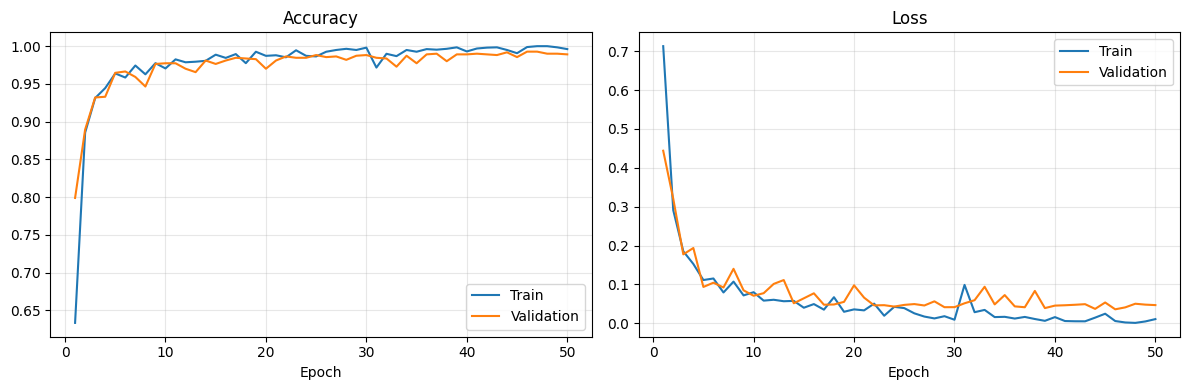

In [11]:
# Plot training curves
def plot_history(h):
    acc, val_acc = h.history['accuracy'], h.history['val_accuracy']
    loss, val_loss = h.history['loss'], h.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train')
    plt.plot(epochs_range, val_acc, label='Validation')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train')
    plt.plot(epochs_range, val_loss, label='Validation')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history)

### Evaluation

Report validation accuracy, a classification report, and a confusion matrix.

Model                          val acc   val loss
-------------------------------------------------
final epoch (paper protocol)    0.9891     0.0470
best checkpoint                 0.9928     0.0362
-------------------------------------------------

Headline (STRICT_PAPER_MODE=True): final-epoch model, val accuracy 0.9891

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step
              precision    recall  f1-score   support

  Brown_Rust      0.974     0.994     0.984       338
     Healthy      0.998     0.988     0.993       419
 Yellow_Rust      0.994     0.986     0.990       347

    accuracy                          0.989      1104
   macro avg      0.989     0.989     0.989      1104
weighted avg      0.989     0.989     0.989      1104

Reproduction vs. paper Table 3
Class          P ours  P paper  R ours  R paper  F1 ours  F1 paper
------------------------------------------------------------------
Brown_Rust      0.974    0.961   0.994    0.961    0.984     0.961
Healthy         0.99

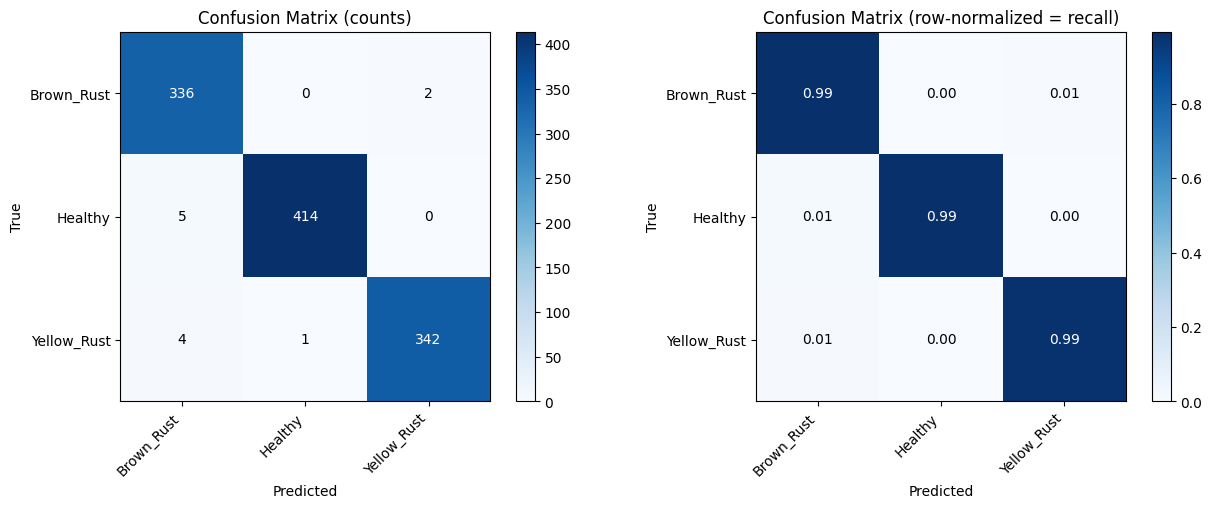


rust <-> rust    misclassifications: 6
rust <-> healthy misclassifications: 6
Paper's claim: errors are mostly YR<->BR, and rust<->healthy is rare.
VERDICT: inconclusive -- the two error types are equally common.


In [12]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)

def _eval(path):
    m = tf.keras.models.load_model(path)
    val_gen.reset()
    loss, acc = m.evaluate(val_gen, verbose=0)
    return m, acc, loss

# Report BOTH: the paper's protocol (final epoch of 50) and the best checkpoint.
m_final, acc_final, loss_final = _eval(FINAL_MODEL_PATH)
m_best,  acc_best,  loss_best  = _eval(MODEL_PATH)

print(f"{'Model':28s}{'val acc':>10s}{'val loss':>11s}")
print('-' * 49)
print(f"{'final epoch (paper protocol)':28s}{acc_final:10.4f}{loss_final:11.4f}")
print(f"{'best checkpoint':28s}{acc_best:10.4f}{loss_best:11.4f}")
print('-' * 49)

# The headline model follows the mode: strict replication reports the final epoch.
model   = m_final if STRICT_PAPER_MODE else m_best
val_acc = acc_final if STRICT_PAPER_MODE else acc_best
print(f"\nHeadline (STRICT_PAPER_MODE={STRICT_PAPER_MODE}): "
      f"{'final-epoch' if STRICT_PAPER_MODE else 'best-checkpoint'} "
      f"model, val accuracy {val_acc:.4f}\n")

val_gen.reset()
y_prob = model.predict(val_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes          # shuffle=False -> aligned with predict() order
assert len(y_pred) == len(y_true), f"length mismatch: {len(y_pred)} vs {len(y_true)}"

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                            digits=3, zero_division=0))

# ---- Side-by-side with the paper's reported Table 3 ----
P, R, F, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0)
PAPER_T3 = {'Yellow_Rust': (0.965, 0.948, 0.956),
            'Brown_Rust':  (0.961, 0.961, 0.961),
            'Healthy':     (0.960, 0.974, 0.966)}

print("Reproduction vs. paper Table 3")
print(f"{'Class':13s}{'P ours':>8s}{'P paper':>9s}{'R ours':>8s}{'R paper':>9s}"
      f"{'F1 ours':>9s}{'F1 paper':>10s}")
print('-' * 66)
for i, name in enumerate(CLASS_NAMES):
    pp, pr, pf = PAPER_T3[name]
    print(f"{name:13s}{P[i]:8.3f}{pp:9.3f}{R[i]:8.3f}{pr:9.3f}{F[i]:9.3f}{pf:10.3f}")
print('-' * 66)
print(f"{'OVERALL ACC':13s}{val_acc:8.3f}{0.960:9.3f}"
      "                          <- paper claims 96%")

# ---- Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (mat, title, fmt) in zip(axes, [
        (cm, 'Confusion Matrix (counts)', 'd'),
        (cm.astype(float) / cm.sum(axis=1, keepdims=True),
         'Confusion Matrix (row-normalized = recall)', '.2f')]):
    im = ax.imshow(mat, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    thr = mat.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(mat[i, j], fmt), ha='center', va='center',
                    color='white' if mat[i, j] > thr else 'black')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# ---- Which confusion dominates? Paper claims YR<->BR, rarely rust<->healthy ----
bi, hi, yi = (CLASS_NAMES.index(c) for c in ('Brown_Rust', 'Healthy', 'Yellow_Rust'))
rust_rust    = cm[bi, yi] + cm[yi, bi]
rust_healthy = cm[bi, hi] + cm[yi, hi] + cm[hi, bi] + cm[hi, yi]
print(f"\nrust <-> rust    misclassifications: {rust_rust}")
print(f"rust <-> healthy misclassifications: {rust_healthy}")
print("Paper's claim: errors are mostly YR<->BR, and rust<->healthy is rare.")
if rust_rust + rust_healthy == 0:
    print("VERDICT: no misclassifications at all -- nothing to compare.")
elif rust_rust > rust_healthy:
    print("VERDICT: consistent with the paper (errors are mostly rust<->rust).")
elif rust_rust == rust_healthy:
    print("VERDICT: inconclusive -- the two error types are equally common.")
else:
    print("VERDICT: NOT consistent -- rust is confused with healthy more often "
          "than with the other rust.")


In [13]:
# Both artifacts are already on disk:
#   MODEL_PATH       -> best-val_accuracy checkpoint (written by ModelCheckpoint)
#   FINAL_MODEL_PATH -> last-epoch weights = the paper's "trained for 50 epochs"
# Do NOT model.save(MODEL_PATH) here: an earlier version of this notebook did,
# which overwrote the good checkpoint with the last-epoch weights.
for _p, _label in ((MODEL_PATH, 'best checkpoint'),
                   (FINAL_MODEL_PATH, 'final epoch (paper protocol)')):
    _m = tf.keras.models.load_model(_p)
    print(f"{_label:32s} {_p:42s} {_m.count_params():>10,} params")

# app.py loads MODEL_PATH. In STRICT_PAPER_MODE the paper's deliverable is the
# final-epoch model, so promote it for deployment.
if STRICT_PAPER_MODE:
    import shutil as _sh
    _sh.copy2(FINAL_MODEL_PATH, MODEL_PATH)
    print(f"\nSTRICT_PAPER_MODE -> promoted final-epoch model to {MODEL_PATH} for app.py")


best checkpoint                  wheat_disease_cnn.keras                     2,175,683 params
final epoch (paper protocol)     wheat_disease_cnn_final_epoch.keras         2,175,683 params

STRICT_PAPER_MODE -> promoted final-epoch model to wheat_disease_cnn.keras for app.py


### Single-image inference helper

A reusable function that preprocesses one image and returns the predicted disease + confidence. This is what the web app (Step 6) calls under the hood.

In [14]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path_or_pil, model=model):
    """Classify a single wheat-leaf image. Accepts a file path or a PIL.Image.
    Returns (predicted_class, confidence, full_probability_dict)."""
    if isinstance(img_path_or_pil, str):
        img = keras_image.load_img(img_path_or_pil, target_size=IMG_SIZE)
    else:
        img = img_path_or_pil.convert('RGB').resize(IMG_SIZE)

    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))
    prob_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    return CLASS_NAMES[idx], float(probs[idx]), prob_dict

# Demo on one validation image (label from CLASS_NAMES, folder from CLASS_DIRS)
sample_class = CLASS_NAMES[0]
sample_dir = os.path.join(VAL_DIR, VAL_CLASS_DIRS[0])
sample_file = os.path.join(sample_dir, os.listdir(sample_dir)[0])
pred, conf, allp = predict_image(sample_file)
print(f"File: {sample_file}")
print(f"Predicted: {pred}  (confidence {conf:.2%})")
print("All probabilities:", {k: round(v, 3) for k, v in allp.items()})

File: /kaggle/working/data_70_30/val/Brown_Rust/Brown_rust412.jpg
Predicted: Brown_Rust  (confidence 100.00%)
All probabilities: {'Brown_Rust': 1.0, 'Healthy': 0.0, 'Yellow_Rust': 0.0}


## Step 5 — Rule-Based Recommendation Module

A **text-based** system, independent of the image classifier, that:

1. **Extraction** — uses regular expressions to find disease names / symptoms in free-form user text.
2. **Alignment** — matches the extracted terms against a knowledge base of medicinal/treatment recommendations.

It is designed to be exposed over a **REST API** (Step 6).

In [15]:
# ---- Knowledge base: disease -> recommendation (Alignment target) ----
# GAP 1 FIX. The paper's Section 3.3 states the recommendation module covers
# Yellow Rust and Brown Rust PLUS: Powdery Mildew (PM), Septoria Leaf Blotch (SLB),
# Tan Spot (TS), Head Blight (HB/Scab), Loose Smut (LS), Karnal Bunt (KB),
# Root Rot (RR), Leaf Blight (LB), Barley Yellow Dwarf Virus (BYDV), Wheat
# Soilborne Mosaic Virus (WSBMV) and Wheat Streak Mosaic Virus (WSMV)
# -- 13 diseases in total.
#
# This module is TEXT-driven and deliberately independent of the image classifier
# (which only sees 3 classes), exactly as the paper describes.
RECOMMENDATION_DB = {
    'Yellow_Rust': {
        'common_names': ['yellow rust', 'stripe rust', 'yellow stripe', 'yr'],
        'symptoms': ['yellow stripes', 'yellow pustules', 'parallel stripes', 'yellowing leaves'],
        'recommendation': (
            'Apply a triazole fungicide (propiconazole or tebuconazole) at first sign. '
            'Use resistant varieties, avoid excessive nitrogen, and remove volunteer '
            'plants that harbor the pathogen. Monitor during cool, moist weather.'),
    },
    'Brown_Rust': {
        'common_names': ['brown rust', 'leaf rust', 'orange rust', 'br'],
        'symptoms': ['brown pustules', 'orange spots', 'round brown spots', 'reddish-brown spots'],
        'recommendation': (
            'Spray a strobilurin or triazole fungicide (azoxystrobin, tebuconazole) '
            'when pustules appear. Plant rust-resistant cultivars, keep fertilization '
            'balanced, and rotate crops to break the disease cycle.'),
    },
    'Powdery_Mildew': {
        'common_names': ['powdery mildew', 'pm', 'mildew'],
        'symptoms': ['white powdery growth', 'white patches', 'grey-white fungal growth',
                     'powdery coating'],
        'recommendation': (
            'Apply a triazole or strobilurin fungicide at early infection. Avoid dense '
            'canopies and excess nitrogen, widen row spacing for airflow, and grow '
            'resistant cultivars.'),
    },
    'Septoria_Leaf_Blotch': {
        'common_names': ['septoria leaf blotch', 'septoria', 'slb', 'leaf blotch'],
        'symptoms': ['irregular brown lesions', 'black pycnidia', 'oval tan lesions',
                     'leaf blotches'],
        'recommendation': (
            'Apply an azole fungicide (prothioconazole) at flag-leaf emergence. Use '
            'resistant varieties, rotate away from wheat, bury infected residue, and '
            'avoid very early sowing.'),
    },
    'Tan_Spot': {
        'common_names': ['tan spot', 'ts', 'yellow leaf spot', 'red smudge'],
        'symptoms': ['tan lesions with yellow halo', 'lens-shaped lesions', 'dark brown centre',
                     'tan spots'],
        'recommendation': (
            'Rotate away from wheat for at least one season and bury or remove stubble, '
            'which carries the pathogen. Apply a fungicide at flag leaf if lesions reach '
            'the upper canopy, and choose tolerant cultivars.'),
    },
    'Head_Blight': {
        'common_names': ['head blight', 'fusarium head blight', 'scab', 'hb', 'ear blight'],
        'symptoms': ['bleached spikelets', 'pink spore masses', 'shrivelled kernels',
                     'premature whitening of heads'],
        'recommendation': (
            'Spray prothioconazole or tebuconazole at early anthesis (flowering). Avoid '
            'planting into maize stubble, rotate with non-cereals, and use moderately '
            'resistant varieties. Test grain for deoxynivalenol (DON) mycotoxin before use.'),
    },
    'Loose_Smut': {
        'common_names': ['loose smut', 'ls', 'smut'],
        'symptoms': ['black powdery spore mass', 'heads replaced by spores',
                     'destroyed heads', 'black dusty heads'],
        'recommendation': (
            'Systemic seed treatment is the only effective control: treat with carboxin '
            'or tebuconazole before sowing. Always plant certified disease-free seed; '
            'foliar sprays cannot cure a seed-borne infection.'),
    },
    'Karnal_Bunt': {
        'common_names': ['karnal bunt', 'kb', 'partial bunt'],
        'symptoms': ['blackened kernels', 'fishy odour', 'partially bunted grain',
                     'black powder in grain'],
        'recommendation': (
            'Sow certified seed treated with a systemic fungicide, and apply propiconazole '
            'at heading in high-risk seasons. Observe quarantine rules for movement of '
            'grain, and avoid irrigation during flowering in humid conditions.'),
    },
    'Root_Rot': {
        'common_names': ['root rot', 'rr', 'common root rot', 'crown rot'],
        'symptoms': ['brown roots', 'darkened crown', 'stunted growth', 'poor tillering',
                     'whiteheads'],
        'recommendation': (
            'Use a fungicidal seed treatment, rotate with non-host crops, and improve '
            'drainage to avoid waterlogging. Maintain balanced nutrition and avoid deep '
            'sowing, which prolongs seedling vulnerability.'),
    },
    'Leaf_Blight': {
        'common_names': ['leaf blight', 'lb', 'helminthosporium leaf blight',
                        'spot blotch'],
        'symptoms': ['brown oval lesions', 'blighted leaves', 'dark brown spots',
                     'drying leaf tips'],
        'recommendation': (
            'Apply mancozeb or propiconazole at first appearance. Rotate crops, destroy '
            'infected residue, use clean seed, and grow tolerant varieties; the disease '
            'is worst under warm, humid conditions.'),
    },
    'BYDV': {
        'common_names': ['bydv', 'barley yellow dwarf virus', 'barley yellow dwarf',
                        'yellow dwarf'],
        'symptoms': ['yellow leaf tips', 'red-purple leaf discolouration', 'stunting',
                     'reduced tillering'],
        'recommendation': (
            'No cure once plants are infected -- control the aphid vector. Use insecticidal '
            'seed treatment, monitor and spray aphids in autumn, delay sowing to miss peak '
            'aphid flights, and grow tolerant varieties.'),
    },
    'WSBMV': {
        'common_names': ['wsbmv', 'wheat soilborne mosaic virus', 'soilborne mosaic',
                        'soil-borne mosaic'],
        'symptoms': ['mosaic mottling', 'yellow-green mottling', 'stunting',
                     'rosetting in patches'],
        'recommendation': (
            'Resistant varieties are the only practical control -- the virus is spread by '
            'the soil fungus Polymyxa graminis and cannot be treated chemically. Avoid '
            'very early sowing and steer clear of poorly drained fields with a history '
            'of the disease.'),
    },
    'WSMV': {
        'common_names': ['wsmv', 'wheat streak mosaic virus', 'wheat streak mosaic',
                        'streak mosaic'],
        'symptoms': ['yellow streaking', 'parallel yellow streaks', 'mosaic pattern',
                     'stunting'],
        'recommendation': (
            'Destroy volunteer wheat at least two weeks before sowing to break the '
            '"green bridge" that carries the wheat curl mite vector. Delay planting, '
            'control grassy weeds, and use resistant varieties. No chemical cure exists '
            'once plants are infected.'),
    },
    'Healthy': {
        'common_names': ['healthy', 'no disease', 'normal'],
        'symptoms': ['green leaves', 'no spots', 'healthy leaf'],
        'recommendation': (
            'No disease detected. Maintain good agronomic practices: balanced irrigation '
            'and fertilization, regular field scouting, and preventive monitoring during '
            'humid periods.'),
    },
}

# Build a regex-friendly term -> canonical-disease lookup
def build_term_index(db):
    index = {}
    for disease, info in db.items():
        for term in info['common_names'] + info['symptoms']:
            index[term.lower()] = disease
    # Longest phrases first so multi-word terms match before single words
    return dict(sorted(index.items(), key=lambda kv: -len(kv[0])))

TERM_INDEX = build_term_index(RECOMMENDATION_DB)

# Single source of truth: app.py loads this JSON, so the API can never drift
# out of sync with the notebook's knowledge base.
DB_JSON_PATH = 'recommendation_db.json'
with open(DB_JSON_PATH, 'w') as f:
    json.dump(RECOMMENDATION_DB, f, indent=2)

_n_disease = len([k for k in RECOMMENDATION_DB if k != 'Healthy'])
print(f"{len(RECOMMENDATION_DB)} entries ({_n_disease} diseases + Healthy), "
      f"{len(TERM_INDEX)} searchable terms.")
print(f"Written to {DB_JSON_PATH} for app.py.")
print(f"\nPaper Section 3.3 requires 13 diseases -> "
      f"{'OK' if _n_disease >= 13 else 'MISSING ' + str(13 - _n_disease)}")
print('Diseases:', ', '.join(k for k in RECOMMENDATION_DB if k != 'Healthy'))


14 entries (13 diseases + Healthy), 107 searchable terms.
Written to recommendation_db.json for app.py.

Paper Section 3.3 requires 13 diseases -> OK
Diseases: Yellow_Rust, Brown_Rust, Powdery_Mildew, Septoria_Leaf_Blotch, Tan_Spot, Head_Blight, Loose_Smut, Karnal_Bunt, Root_Rot, Leaf_Blight, BYDV, WSBMV, WSMV


In [16]:
def extract_terms(text):
    """Extraction step: use regex to find known disease names / symptoms in user text."""
    text_l = text.lower()
    matched = []
    for term, disease in TERM_INDEX.items():
        # \b word boundaries so 'rust' doesn't match inside 'trust', etc.
        pattern = r'\b' + re.escape(term) + r'\b'
        if re.search(pattern, text_l):
            matched.append((term, disease))
    return matched

def recommend_from_text(text):
    """Full pipeline: Extraction -> Alignment -> recommendation."""
    matches = extract_terms(text)
    if not matches:
        return {
            'query': text,
            'matched_terms': [],
            'diseases': [],
            'recommendations': [],
            'message': 'No known disease or symptom recognized. Please rephrase or upload an image.',
        }

    # Alignment: collect unique diseases in order of appearance
    diseases = list(dict.fromkeys(d for _, d in matches))
    return {
        'query': text,
        'matched_terms': [t for t, _ in matches],
        'diseases': diseases,
        'recommendations': [
            {'disease': d, 'recommendation': RECOMMENDATION_DB[d]['recommendation']}
            for d in diseases
        ],
        'message': 'ok',
    }

# ---- Try it out ----
for q in [
    "My wheat leaves have yellow stripes running along them",
    "I see round brown spots and orange pustules on the crop",
    "How do I treat yellow rust?",
    "The leaves look green and healthy",
    "there is something wrong but I am not sure",
]:
    r = recommend_from_text(q)
    print(f"Q: {q}")
    print(f"   matched: {r['matched_terms']} -> diseases: {r['diseases']}")
    for rec in r['recommendations']:
        print(f"   [{rec['disease']}] {rec['recommendation'][:80]}...")
    print()

Q: My wheat leaves have yellow stripes running along them
   matched: ['yellow stripes'] -> diseases: ['Yellow_Rust']
   [Yellow_Rust] Apply a triazole fungicide (propiconazole or tebuconazole) at first sign. Use re...

Q: I see round brown spots and orange pustules on the crop
   matched: ['round brown spots'] -> diseases: ['Brown_Rust']
   [Brown_Rust] Spray a strobilurin or triazole fungicide (azoxystrobin, tebuconazole) when pust...

Q: How do I treat yellow rust?
   matched: ['yellow rust'] -> diseases: ['Yellow_Rust']
   [Yellow_Rust] Apply a triazole fungicide (propiconazole or tebuconazole) at first sign. Use re...

Q: The leaves look green and healthy
   matched: ['healthy'] -> diseases: ['Healthy']
   [Healthy] No disease detected. Maintain good agronomic practices: balanced irrigation and ...

Q: there is something wrong but I am not sure
   matched: [] -> diseases: []

